Run: 1
initial points: 190
Preparing GPs...


Iteration 1
Fitting GPs...
Finding next point...

mu: -2.2234342240967173, sigma: 0.08637607467681896, best: -0.6922007959418566, xi: -2.0, z: 40.88207806811288, ei: 3.5312334281548607, prob1: [0.99639449], prob2: [0.99554954], prob3: [0.9962247], EI: [3.48961829]

Optimized Kernel Y: Matern(length_scale=[11.9, 15.7, 11.5, 18.1, 27.5, 35, 26.3, 29.6, 1e+03, 30.9, 41.7, 1e+03, 32.1, 37.8, 1e+03, 30.1, 39.1, 1e+03, 468], nu=1.5) + RBF(length_scale=15.5)
Optimized Kernel freq1: Matern(length_scale=[4.37, 4.64, 9.18, 7.77, 14.5, 16.6, 1e+03, 37.9, 21.2, 178, 34.5, 13.9, 1e+03, 88.3, 15.4, 275, 89.3, 17.6, 1e+03], nu=2.5) + RBF(length_scale=1e+05)
Optimized Kernel freq2: Matern(length_scale=[4.9, 5.63, 13.4, 26.1, 1e+03, 5.98, 305, 26.5, 14.9, 174, 472, 17.9, 27.3, 18.1, 34.9, 17.6, 14.8, 1e+03, 1e+03], nu=2.5) + RBF(length_scale=1e+05)
Optimized Kernel freq3: Matern(length_scale=[3.61, 6.97, 7.08, 11.4, 13.8, 8.35, 16.8, 21.6, 53.7, 42.7, 17.3,

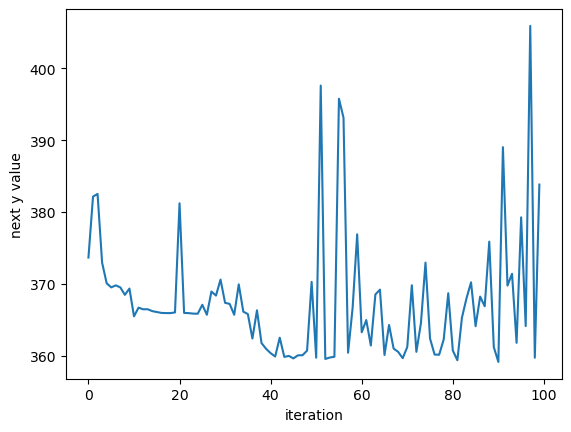

In [21]:
'''
kernel smaller mu, significantly reduced time
X wider bounds cross section
X initial points to 500, significantly increases time
initial points to 200
RBF kernel 
xi 
seed
'''

import numpy as np
import time
from scipy.optimize import minimize, differential_evolution
from scipy.stats import norm, qmc
from scipy.stats.qmc import LatinHypercube
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel, RationalQuadratic, DotProduct
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt

import sys
sys.path.append('../pyJive/')

from utils import proputils as pu
import main
from names import GlobNames as gn
from names import ParamNames as pn

import io
import contextlib

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

def update_geom_file(geom_path, y_coord, update_lines, output_path=None):
    output_path = output_path or geom_path  # Overwrite if no output path provided

    # Read the .geom file
    with open(geom_path, 'r') as file:
        lines = file.readlines()

    # Locate and modify the section with upper node coordinates
    for i in range(len(lines)):
        if i in update_lines:
            parts = lines[i].split()
            parts[-1] = str(y_coord)  # Modify the last value
            lines[i] = ' '.join(parts) + '\n'        
            
    # Write back the updated file
    with open(output_path, 'w') as file:
        file.writelines(lines)
        

def finite_element_solver(x, n_heights, n_areas):
    # DOES ONLY WORK FOR 6 DIMENSIONS
    y_coord = x[:n_heights]
    area = x[n_heights:]
    update_lines = [[3, 19], [5, 17], [7, 15], [9, 13], [11,]]
    
    for i in range(n_heights):
        update_geom_file('bridge.geom', y_coord[i], update_lines[i], output_path=None)
    
    # Load properties
    props = pu.parse_file('bridge_frequency.pro')
    
    # Update cross-section area
    props['model']['truss']['area'] = np.concatenate(([40e-4], area))
    
    # Run FEM simulation
    with contextlib.redirect_stdout(io.StringIO()):
        globdat = main.jive(props)

    # Extract mass  
    mass_nodes = props['model']['mass']['nodeGroup']
    n_bottom_nodes = len(globdat[gn.NGROUPS][mass_nodes])
    point_mass = float(props['model']['mass']['mass'])
    weight = 0.5 * np.sum(globdat[pn.MATRIX2]) - n_bottom_nodes * point_mass
    
    # Extract natural frequencies
    freq1 = globdat[gn.EIGENFREQS][0] / (2 * np.pi)
    freq2 = globdat[gn.EIGENFREQS][1] / (2 * np.pi)
    freq3 = globdat[gn.EIGENFREQS][2] / (2 * np.pi)

    return weight, freq1, freq2, freq3


def feasibility_probability(x, gp_freq, threshold):
    mu, sigma = gp_freq.predict(x.reshape(1, -1), return_std=True)
    prob = norm.cdf((threshold - mu) / (sigma))
    
    return prob


def EI(x, gp_Y, gp_freq1, gp_freq2, gp_freq3, Y_samples, threshold1, threshold2, threshold3, input_scaler, output_scaler, n_dim, xi, best_y):
    mu, sigma = gp_Y.predict(x.reshape(1, -1), return_std=True)
    mu, sigma = mu[0], sigma[0]
    best = best_y
    
    z = (best - mu - xi) / (sigma)
    ei = (best - mu - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    
    prob1 = 1 - feasibility_probability(x, gp_freq1, threshold1)
    prob2 = 1 - feasibility_probability(x, gp_freq2, threshold2)
    prob3 = 1 - feasibility_probability(x, gp_freq3, threshold3)
    
    # print('x', input_scaler.inverse_transform(x.reshape(-1, n_dim))[0])
    # print('mu', output_scaler.inverse_transform(mu.reshape(-1, 1))[0, 0])
    # print(f"x:, {x}, mu: {mu}, sigma: {sigma}, best: {best}, z: {z}, ei: {ei}, prob1: {prob1}, prob2: {prob2}, prob3: {prob3}")
    print('')
    print(f"mu: {mu}, sigma: {sigma}, best: {best}, xi: {xi}, z: {z}, ei: {ei}, prob1: {prob1}, prob2: {prob2}, prob3: {prob3}, EI: {ei * prob1 * prob2 * prob3}")
    
    return -ei * prob1 * prob2 * prob3
    
    
def restart_differential_evolution(acquisition_func, bounds, n_restarts=10):
    best_x = None
    best_value = float('inf')
    
    for restart in range(n_restarts):
        result = differential_evolution(
            lambda x: acquisition_func(x), 
            bounds=bounds, 
            strategy='best1bin', 
            popsize=5,  # 5 * 19 = 95 population size
            maxiter=10,  # Small maxiter, we restart after 10 iterations
            tol=1e-6, 
            polish=True
        )
        if result.fun < best_value:
            best_value = result.fun
            best_x = result.x

        # print(f"Restart {restart + 1}/{n_restarts}, Best Value: {best_value}")
    
    return best_x


def hybrid_acquisition_optimization(acquisition_func, bounds):
    result_de = differential_evolution(lambda x: acquisition_func(x), 
                                   bounds=bounds, 
                                   strategy='best1bin', 
                                   popsize=10,  # 5 * dim
                                   maxiter=10, 
                                   tol=1e-6, 
                                   polish=False)  # Do not polish with DE

    # Step 2: Local refinement with L-BFGS-B
    result_l_bfgs = minimize(acquisition_func, 
                         result_de.x, 
                         method='L-BFGS-B', 
                         bounds=bounds, 
                         options={'maxiter': 100, 'ftol': 1e-6})
    
    return result_l_bfgs.x


def adaptive_xi_linear(iteration, max_iterations, xi_max=1, xi_min=-0.5):
    """Linearly decreases xi from xi_max to xi_min."""
    return xi_max - (xi_max - xi_min) * (iteration / max_iterations)


def generate_lhs_samples_height(num_samples, bounds, lhs_ratio=0.5):
    
    dimensions = len(bounds)
    assert dimensions >= 2, "Number of dimensions must be at least 2."

    lower_bound, upper_bound = bounds[0][0], bounds[-1][1]
    
    # Step 1: Sample x1 and x5 independently
    x1 = np.random.uniform(lower_bound, upper_bound, size=num_samples)
    x5 = np.random.uniform(lower_bound, upper_bound, size=num_samples)
    
    # Ensure x1 < x5
    x1, x5 = np.minimum(x1, x5), np.maximum(x1, x5)
    
    # Step 2: Sample remaining points uniformly between x1 and x5
    intermediate_points = np.random.uniform(x1[:, None], x5[:, None], size=(num_samples, dimensions - 2))
    
    # Combine x1, intermediate points, and x5
    all_points = np.hstack([x1.reshape(-1, 1), intermediate_points, x5.reshape(-1, 1)])
    
    # Step 3: Sort to enforce monotonicity
    monotonic_samples = np.sort(all_points, axis=1)
    
    return monotonic_samples


def generate_lhs_samples_area(num_samples, bounds):
    """
    Generate Latin Hypercube Sampling (LHS) points.

    Parameters:
    - num_samples (int): Number of points to sample (N).
    - bounds (array-like): A Dx2 list where D is the number of dimensions.
      Each row specifies [lower_bound, upper_bound] for the corresponding dimension.

    Returns:
    - samples (numpy.ndarray): Array of shape (num_samples, dimensions) containing the LHS points.
    """
    # Extract dimensions from bounds
    dimensions = len(bounds)

    # Initialize LHS sampler
    sampler = LatinHypercube(d=dimensions)

    # Generate LHS points in [0, 1]^D space
    lhs_points = sampler.random(n=num_samples)

    # Scale points to the specified bounds
    bounds = np.array(bounds)
    lower_bounds = bounds[:, 0]
    upper_bounds = bounds[:, 1]

    # Scale points to the [lower_bounds, upper_bounds] range
    scaled_points = lower_bounds + (upper_bounds - lower_bounds) * lhs_points

    return scaled_points




def bayesian_optimization(n_iter=100):   
    np.random.seed(24)
    
    n_heights = 5
    n_areas = 14
    n_dim = n_heights + n_areas
    
    n_init = 190
    
    print(f'initial points: {n_init}')
    print('Preparing GPs...')
    
    bounds_height_unscaled = np.tile([0.2, 2.5], (n_heights, 1))
    bounds_area_unscaled = np.tile([1e-4, 10e-4], (n_areas, 1))
    bounds_unscaled = np.vstack((bounds_height_unscaled, bounds_area_unscaled))
    
    threshold1_unscaled = 20
    threshold2_unscaled = 40
    threshold3_unscaled = 60
    
    X_height_unscaled = generate_lhs_samples_height(num_samples=n_init, bounds=bounds_height_unscaled)
    X_area_unscaled = generate_lhs_samples_area(num_samples=n_init, bounds=bounds_area_unscaled)
    X_samples_unscaled = np.column_stack((X_height_unscaled, X_area_unscaled))
    
    with contextlib.redirect_stdout(io.StringIO()):
        output = np.array([finite_element_solver(x, n_heights, n_areas) for x in X_samples_unscaled])
    
    Y_samples_unscaled = output[:, 0]
    freq1_samples_unscaled = output[:, 1]
    freq2_samples_unscaled = output[:, 2]
    freq3_samples_unscaled = output[:, 3]
    
    input_scaler = StandardScaler()
    output_scaler = StandardScaler()
    freq1_scaler = MinMaxScaler()
    freq2_scaler = MinMaxScaler()
    freq3_scaler = MinMaxScaler()
    
    X_samples = input_scaler.fit_transform(X_samples_unscaled)
    Y_samples = output_scaler.fit_transform(Y_samples_unscaled.reshape(-1, 1)).flatten()
    freq1_samples = freq1_scaler.fit_transform(freq1_samples_unscaled.reshape(-1, 1)).flatten()
    freq2_samples = freq2_scaler.fit_transform(freq2_samples_unscaled.reshape(-1, 1)).flatten()
    freq3_samples = freq3_scaler.fit_transform(freq3_samples_unscaled.reshape(-1, 1)).flatten()
    
    bounds = input_scaler.transform(bounds_unscaled.T).T
    threshold1 = freq1_scaler.transform(np.array(threshold1_unscaled).reshape(-1, 1))[0, 0]
    threshold2 = freq2_scaler.transform(np.array(threshold2_unscaled).reshape(-1, 1))[0, 0]
    threshold3 = freq3_scaler.transform(np.array(threshold3_unscaled).reshape(-1, 1))[0, 0]
    
    kernel_Y = Matern(length_scale=[10] * 19, nu=1.5, length_scale_bounds=(0.1, 1000)) + RBF(length_scale=10)
    kernel_freq1 = Matern(length_scale=[10] * 19, nu=2.5, length_scale_bounds=(0.1, 1000)) + RBF(length_scale=10)
    kernel_freq2 = Matern(length_scale=[10] * 19, nu=2.5, length_scale_bounds=(0.1, 1000)) + RBF(length_scale=10)
    kernel_freq3 = Matern(length_scale=[10] * 19, nu=2.5, length_scale_bounds=(0.1, 1000)) + RBF(length_scale=10)
  
    gp_Y = GaussianProcessRegressor(kernel=kernel_Y, alpha=0)
    gp_freq1 = GaussianProcessRegressor(kernel=kernel_freq1, alpha=0)
    gp_freq2 = GaussianProcessRegressor(kernel=kernel_freq2, alpha=0)
    gp_freq3 = GaussianProcessRegressor(kernel=kernel_freq3, alpha=0)
    
    valid_idx = np.where((freq1_samples >= threshold1) & (freq2_samples >= threshold2) & (freq3_samples >= threshold3))[0]
    best_y = np.min(Y_samples[valid_idx])
    
    y_next_list = []
    for iteration in range(n_iter):
            
        print('')
        print('')
        print(f'Iteration {iteration + 1}') 
        print('Fitting GPs...')

        gp_Y.fit(X_samples, Y_samples)
        gp_freq1.fit(X_samples, freq1_samples)
        gp_freq2.fit(X_samples, freq2_samples)
        gp_freq3.fit(X_samples, freq3_samples)
        
        print('Finding next point...')
        
        xi = adaptive_xi_linear(iteration, n_iter, xi_max=-2, xi_min=-8)
        
        def acquisition(x):
            return EI(x, gp_Y, gp_freq1, gp_freq2, gp_freq3, Y_samples, threshold1, threshold2, threshold3, input_scaler, output_scaler, n_dim, xi, best_y)
        
        with contextlib.redirect_stdout(io.StringIO()):
            x_next = differential_evolution(lambda x: acquisition(x), bounds=bounds, strategy='best1bin', popsize=5, maxiter=10, tol=1e-6, polish=True).x
        
        x_next_unscaled = input_scaler.inverse_transform(x_next.reshape(-1, n_dim))[0]
        
        output_next_unscaled = finite_element_solver(x_next_unscaled, n_heights, n_areas)
        y_next_unscaled = output_next_unscaled[0]
        freq1_next_unscaled = output_next_unscaled[1]
        freq2_next_unscaled = output_next_unscaled[2]
        freq3_next_unscaled = output_next_unscaled[3]
        
        EI_next = acquisition(x_next)
        y_next = output_scaler.transform(y_next_unscaled.reshape(-1, 1))[0]
        freq1_next = freq1_scaler.transform(freq1_next_unscaled.reshape(-1, 1))[0]
        freq2_next = freq2_scaler.transform(freq2_next_unscaled.reshape(-1, 1))[0]
        freq3_next = freq3_scaler.transform(freq3_next_unscaled.reshape(-1, 1))[0]
        
        X_samples = np.vstack((X_samples, x_next))
        Y_samples = np.append(Y_samples, y_next)        
        freq1_samples = np.append(freq1_samples, freq1_next)
        freq2_samples = np.append(freq2_samples, freq2_next)
        freq3_samples = np.append(freq3_samples, freq3_next)
        
        valid_idx = np.where((freq1_samples >= threshold1) & (freq2_samples >= threshold2) & (freq3_samples >= threshold3))[0]
        best_y = np.min(Y_samples[valid_idx])
        y_next_list.append(y_next_unscaled)
        best_y_unscaled = output_scaler.inverse_transform(best_y.reshape(-1, 1))[0][0]
        
        print('')
        print("Optimized Kernel Y:", gp_Y.kernel_)
        print("Optimized Kernel freq1:", gp_freq1.kernel_)
        print("Optimized Kernel freq2:", gp_freq2.kernel_)
        print("Optimized Kernel freq3:", gp_freq3.kernel_)
        print('')
        print(f'time: {time.time() - start_time}')
        print(f'height: {x_next_unscaled[:n_heights]}')
        print(f'area: {x_next_unscaled[n_heights:]}')
        print(f'best weight: {best_y_unscaled}')
        print(f'weight: {y_next_unscaled}')
        print(f'freq1: {freq1_next_unscaled}')
        print(f'freq2: {freq2_next_unscaled}')
        print(f'freq3: {freq3_next_unscaled}')
        print('')
        
    plt.plot(y_next_list)
    plt.xlabel('iteration')
    plt.ylabel('next y value')
    
    valid_idx = np.where((freq1_samples >= threshold1) & (freq2_samples >= threshold2) & (freq3_samples >= threshold3))[0]
    best_idx = valid_idx[np.argmin(Y_samples[valid_idx])]
    best_x_unscaled = input_scaler.inverse_transform(X_samples[best_idx].reshape(-1, n_dim))[0]
    best_y_unscaled = output_scaler.inverse_transform(Y_samples[best_idx].reshape(-1, 1))[0, 0]
    best_freq1_unscaled = freq1_scaler.inverse_transform(freq1_samples[best_idx].reshape(-1, 1))[0, 0]
    best_freq2_unscaled = freq2_scaler.inverse_transform(freq2_samples[best_idx].reshape(-1, 1))[0, 0]
    best_freq3_unscaled = freq3_scaler.inverse_transform(freq3_samples[best_idx].reshape(-1, 1))[0, 0]
    
    return best_x_unscaled[:n_heights], best_x_unscaled[n_heights:], best_y_unscaled, best_freq1_unscaled, best_freq2_unscaled, best_freq3_unscaled


for i in range(1):
    print(f'Run: {i+1}')
    
    start_time = time.time()
    height, area, weight, freq1, freq2, freq3 = bayesian_optimization()
    end_time = time.time()

    print('Best values')
    print(f'time: {end_time - start_time}')
    print(f'height: {height}')
    print(f'area: {area}')
    print(f'weight: {weight}')
    print(f'freq1: {freq1}')
    print(f'freq2: {freq2}')
    print(f'freq3: {freq3}')
    print('')
    print('')